# Karan Bedi - Prodigal AI Assignment
## Task 1 - Prompting: Zero-Shot and Few-Shot


## Libraries

These imports support three parts of the experiment: loading and evaluating Yelp data, calling hosted LLM APIs, and running a local Gemma model. Keeping the API and local-model dependencies in the same notebook was intentional because the experiment changed direction when hosted access became unreliable.

**Engineering note:** The first experiments used Gemini 2.5 Flash and Claude Haiku as hosted baselines. In practice, Gemini hit rate limits during evaluation and Claude could not be used further after the free-tier credits were exhausted. Rather than treating this as a blocker, I pivoted to Gemma 2B running locally on an RTX 4060 Ti through Parsec remote desktop.

This decision was made to keep the evaluation reproducible and to avoid depending on a single external service. In production systems, API failures, quota limits, and billing constraints are normal operational risks. A local fallback may be smaller and less accurate, but it keeps the pipeline available when hosted models fail.


In [73]:
import json
import os
import re
import time
from datetime import datetime
import torch
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from datasets import load_dataset
from dotenv import load_dotenv
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig
from sklearn.metrics import accuracy_score, f1_score
import google.generativeai as genai
import anthropic

## Loading the Dataset

The Yelp Review Full dataset is used because it is a five-class sentiment task rather than a simple positive/negative split. This makes the prompt design more meaningful: adjacent ratings such as 2-star and 3-star require the model to understand intensity, not just polarity. The Hugging Face labels are zero-indexed, so adding 1 converts them to the expected 1-5 star scale.


## Sample Size

Task 1 uses a 15-sample slice so that prompt iterations can run quickly on local hardware. This is a trade-off: the sample is too small for broad statistical claims, but large enough to expose the main failure modes, especially JSON compliance and rating collapse.


In [74]:
dataset = load_dataset('yelp_review_full', split='test[:15]')
# While ive loaded the full dataset, ill be using a small sample
dataset = dataset.map(lambda x: {"stars": x["label"] + 1})# This is 0 indexed, we want stars from 1-5

## Zero-Shot Prompt

Zero-shot prompting is the baseline because the model receives only the instruction and the review. This tests whether the task description alone is enough for Gemma 2B to infer both the star-rating scale and the required JSON format. The result supports the decision about whether examples are necessary.


In [75]:
ZERO_SHOT_SYSTEM = """You are a sentiment classifier for Yelp reviews.
Classify the review into 1-5 stars.
Return ONLY valid JSON. No other text.

Format:
{"stars": <1-5>, "explanation": ""}
"""

In [76]:
def zero_shot_classify(review_text, llm_call):
    prompt = f"Review: {review_text[:500]}"
    
    raw = llm_call(prompt, ZERO_SHOT_SYSTEM)
    raw = clean_json(raw)
    
    try:
        return json.loads(raw), True
    except:
        return None, False

## Few-Shot Prompt and Examples

The few-shot version adds one labelled example for each star rating. This decision was made to give the model both format anchors and calibration anchors: it sees what valid JSON looks like and how different sentiment intensities map to 1-5 stars before it classifies the target review.


In [77]:
FEW_SHOT_EXAMPLES = """
Review: Absolutely terrible. Cold food, rude staff.
{"stars": 1, "explanation": "Strong negative sentiment."}

Review: Below average. Nothing special.
{"stars": 2, "explanation": "Mild dissatisfaction."}

Review: Decent place, nothing memorable.
{"stars": 3, "explanation": "Neutral experience."}

Review: Really enjoyed it. Would come back.
{"stars": 4, "explanation": "Positive experience."}

Review: Incredible experience. Best meal ever!
{"stars": 5, "explanation": "Strong positive sentiment."}
"""

In [78]:
def few_shot_classify(review_text, llm_call):
    prompt = FEW_SHOT_EXAMPLES + f"\nReview: {review_text[:500]}"
    
    raw = llm_call(prompt, ZERO_SHOT_SYSTEM)
    raw = clean_json(raw)
    
    try:
        return json.loads(raw), True
    except:
        return None, False

## Gemini API Configuration

Gemini 2.5 Flash was tested first as a hosted reference model. The environment variables are loaded explicitly because the notebook can run from WSL, where the working directory and Windows project path do not always line up. This reduces setup ambiguity before the API call is made.


In [79]:
# I am using WSL for my kernel, as i have GPU accleration enabled, due to path issues the standard load wont work 
#load_dotenv()
load_dotenv("/mnt/d/School NEw/ProdigalINterviewTest/.env") # I have explicitly defined the path, as i am using WSL, which i have found to be more stable for managing enviromnents especially for gpu acceleration
genai.configure(api_key=os.getenv("GEMINI_API_KEY")) # For security reasons I am using a .env file to store my api key, and ive added it to .gitignore to stop me from accidentaly sharing the api key, (best practices)


In [80]:
MODEL_NAME = "gemini-2.5-flash"  # As i am a free user we will  be proceeding with this, but as a business user we may use pro models, or non gemini models such as Anthropic's Claude or OpenAi's Chat GPT-4

## Model Wrapper

The wrapper standardises the model call interface. This decision was made so the evaluation code could stay unchanged while switching between Gemini, Claude, and Gemma. Separating model access from evaluation makes the comparison easier to reproduce once API access is available again.


In [81]:
# I have simply followed googles documentation to create this wrapper
def llm_call(prompt, system=None):
    # Using the client we initialized above
    response = client.models.generate_content(
        model=MODEL_NAME,
        contents=prompt,
        config=genai.types.GenerateContentConfig(
            system_instruction=system,
            temperature=0,
            max_output_tokens=300,
        )
    )
    return response.text.strip()

In [82]:
results = []

for row in dataset:
    try:
        zs_result, zs_ok = zero_shot_classify(row['text'], llm_call)
        fs_result, fs_ok = few_shot_classify(row['text'], llm_call)
        
        results.append({
            "true_stars": row['stars'],
            "zs_stars": zs_result["stars"] if zs_ok else None,
            "fs_stars": fs_result["stars"] if fs_ok else None,
            "zs_format_ok": zs_ok,
            "fs_format_ok": fs_ok
        })
    except :
        print('Rate limit exceeded')#Helpful as a free user
        break

Rate limit exceeded


## Pivot to Claude Haiku

After Gemini rate limits stopped the first run, Claude Haiku was tested through the same wrapper. This was a practical attempt to keep the hosted-model comparison alive without rewriting the classifier or evaluation logic.


In [83]:
client = anthropic.Anthropic(
    api_key=os.getenv("ANTHROPIC_API_KEY")
)
 
MODEL_NAME = "claude-3-5-haiku-20241022"

In [84]:
# Following the Anthropic documentation to create this 
def llm_call(prompt, system=None):
    # Set up the base parameters
    api_params = {
        "model": MODEL_NAME,
        "max_tokens": 300,
        "temperature": 0,
        "messages": [
            {"role": "user", "content": prompt}
        ]
    }
    
    # Adding our prompt template
    if system:
        api_params["system"] = system   
    # Calling the api
    response = client.messages.create(**api_params)
    return response.content[0].text.strip()

In [85]:
results = []
for row in dataset:
    try:
        zs_result, zs_ok = zero_shot_classify(row['text'], llm_call)
        fs_result, fs_ok = few_shot_classify(row['text'], llm_call)
        
        results.append({
            "true_stars": row['stars'],
            "zs_stars": zs_result["stars"] if zs_ok else None,
            "fs_stars": fs_result["stars"] if fs_ok else None,
            "zs_format_ok": zs_ok,
            "fs_format_ok": fs_ok
        }) 
    except anthropic.BadRequestError as e:# Handles bad requests
        print(f"Halting execution: Bad Request Error. Details: {e}")
        break     
    except anthropic.RateLimitError as e:# As i often run into rate limits as a free user i followadded this
        print(f"Halting execution: Rate limit or balance issue. Details: {e}")
        break 
    except Exception as e:
        # Catches any other random errors (like network drops) so your script doesn't crash
        print(f"Skipping row due to unexpected error: {e}")
        # This is just for specific cases

# Print or process results as needed
print(f"Processed {len(results)} rows.")

/tmp/ipykernel_48400/593277430.py:17: DeprecationWarning: The model 'claude-3-5-haiku-20241022' is deprecated and will reach end-of-life on February 19th, 2026.
Please migrate to a newer model. Visit https://docs.anthropic.com/en/docs/resources/model-deprecations for more information.
  response = client.messages.create(**api_params)


Halting execution: Bad Request Error. Details: Error code: 400 - {'type': 'error', 'error': {'type': 'invalid_request_error', 'message': 'Your credit balance is too low to access the Anthropic API. Please go to Plans & Billing to upgrade or purchase credits.'}, 'request_id': 'req_011Ca97mYkSV4QopW3tERX6j'}
Processed 0 rows.


## API Constraints and Local Fallback

The initial plan was to compare hosted models before running the local baseline. In practice, two constraints appeared immediately: Gemini 2.5 Flash hit free-tier rate limits during evaluation, and Claude Haiku could not continue once the free-tier credits were exhausted.

The engineering decision was to pivot to Gemma 2B running locally on an RTX 4060 Ti through Parsec remote desktop. This was not a downgrade in the experiment design; it was a reliability decision. A smaller local model gives up some accuracy, but it allows unlimited iteration, reproducible runs, and no dependency on external quotas.

This suggests an important production lesson: LLM systems should have a fallback path when APIs fail. Hosted models are useful, but rate limits, billing issues, downtime, and policy changes can interrupt a workflow. A local fallback keeps development and evaluation moving under real constraints.


## Hardware Check

Before loading Gemma, the notebook confirms that CUDA is available and that the expected GPU is active. This matters because the later configuration assumes local GPU inference; if the model falls back to CPU, the same evaluation loop becomes too slow for practical iteration.


In [86]:
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
NVIDIA GeForce RTX 4060 Ti


In [87]:
model_id = "google/gemma-2b-it"

# Check if model already exists in memory before loading incase you have to run all 
if 'model' not in globals() or 'tokenizer' not in globals():
    print(f"Loading {model_id} into memory...")
    
    # Since i only have 8gb vram i will run a 4-bit quantized model
    bnb_config = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_compute_dtype=torch.float16,   #fastest safe option without halucinations 
        bnb_4bit_use_double_quant=True,
        bnb_4bit_quant_type="nf4"              # better accuracy than default
    )

    # tokenizer
    tokenizer = AutoTokenizer.from_pretrained(model_id)

    #Load model efficiently to address slow down
    model = AutoModelForCausalLM.from_pretrained(
        model_id,
        device_map="auto",
        quantization_config=bnb_config,
        torch_dtype=torch.float16,             # ensures fast compute
        low_cpu_mem_usage=True                 # reduces overhead
    )

    #its a faster mode
    model.eval()
    print("Model loaded successfully on:", model.device)
    
else:
    print(f"Model already loaded in memory on: {model.device}. Skipping initialization.")

Model already loaded in memory on: cuda:0. Skipping initialization.


## Gemma 2B LLM Call

This call uses raw prompt concatenation, which later turned out to be an important limitation. Gemma-2b-it is instruction-tuned and follows instructions more reliably when prompts are passed through `apply_chat_template`. This suggests that some Task 1 failures are pipeline-related rather than purely model-capability failures.


In [88]:
def llm_call(prompt, system=None, max_new_tokens=150):
    full_prompt = ""
    if system:
        full_prompt += system + "\n\n"
    full_prompt += prompt
    inputs = tokenizer(full_prompt, return_tensors="pt").to("cuda")
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            use_cache=True
        )
    response = tokenizer.decode(outputs[0], skip_special_tokens=True)
    response = response.replace(full_prompt, "").strip()
    return response

In [89]:
# Stronger than a plain markdown-strip: extracts the first well-formed {...} block,
# so prose the model emits before the JSON is discarded rather than breaking parse.
def clean_json(text):
    # remove markdown
    text = re.sub(r"```json|```", "", text)

    # extract JSON object ONLY
    match = re.search(r"\{[^{}]*\}", text)

    if match:
        return match.group(0)

    return None

In [90]:
def safe_parse(text):# My output was not in proper json thus this extra layer
    if text is None:
        return None, False
    
    try:
        return json.loads(text), True
    except:
        return None, False

## Zero-Shot Prompting with Gemma 2B

This run tests the hardest setting for the local model: no examples and no format demonstration. The expected risk is that the model understands the sentiment but produces prose instead of valid JSON, which makes the prediction unusable for automated evaluation.


### Prompt

The prompt is intentionally minimal so the zero-shot result reflects instruction-following ability rather than example imitation.


In [91]:
ZERO_SHOT_SYSTEM = """You are a strict JSON generator.

Task: Classify the review into 1-5 stars.

You MUST return ONLY a valid JSON object.

NO extra text.
NO explanation outside JSON.
NO sentences before or after.

Output format:
{"stars": 1, "explanation": "..."}

If you output anything else, it is incorrect.
"""

### Classifier

The classifier applies the prompt consistently across the sample so the comparison with few-shot depends on prompt strategy, not evaluation code.


In [92]:
def zero_shot_classify(text):
    prompt = f"Review: {text[:250]}"

    raw = llm_call(prompt, ZERO_SHOT_SYSTEM)
    
    cleaned = clean_json(raw)
    parsed, ok = safe_parse(cleaned)

    return parsed, ok

## Few-Shot Prompting with Gemma 2B

Few-shot prompting adds examples before the target review. This decision was made to reduce two failure modes at once: invalid JSON and weak star calibration. If performance improves, it suggests the model benefits from concrete demonstrations more than abstract instructions.


### Prompt

The examples cover the full rating range so the model sees both negative and positive anchors before generating its own output.


In [93]:
FEW_SHOT_EXAMPLES = """You are a strict JSON generator.

Task: Classify the review into 1-5 stars.

You MUST return ONLY a valid JSON object.
No extra text.

Examples:

Review: Absolutely terrible. Cold food, rude staff.
{"stars": 1, "explanation": "Strong negative sentiment."}

Review: Below average. Nothing special.
{"stars": 2, "explanation": "Mild dissatisfaction."}

Review: Decent place, nothing memorable.
{"stars": 3, "explanation": "Neutral experience."}

Review: Really enjoyed it. Would come back.
{"stars": 4, "explanation": "Positive experience."}

Review: Incredible experience. Best meal ever!
{"stars": 5, "explanation": "Strong positive sentiment."}
"""

### Classifier

The classifier is kept parallel to the zero-shot version so the result isolates the impact of examples.


In [94]:
def few_shot_classify(text):
    prompt = FEW_SHOT_EXAMPLES + f"\n\nReview: {text[:250]}"
    raw = llm_call(prompt)
    cleaned = clean_json(raw)
    parsed, ok = safe_parse(cleaned)
    return parsed, ok

In [95]:
results = []

for row in dataset:

    zs_result, zs_ok = zero_shot_classify(row["text"])
    fs_result, fs_ok = few_shot_classify(row["text"])

    results.append({
        "true_stars": row["stars"],
        "zs_stars": zs_result["stars"] if zs_ok else None,
        "fs_stars": fs_result["stars"] if fs_ok else None,
        "zs_format_ok": zs_ok,
        "fs_format_ok": fs_ok
    })

In [96]:
print(results)

[{'true_stars': 1, 'zs_stars': 3, 'fs_stars': 1, 'zs_format_ok': True, 'fs_format_ok': True}, {'true_stars': 1, 'zs_stars': None, 'fs_stars': 1, 'zs_format_ok': False, 'fs_format_ok': True}, {'true_stars': 1, 'zs_stars': 2, 'fs_stars': 1, 'zs_format_ok': True, 'fs_format_ok': True}, {'true_stars': 1, 'zs_stars': 2, 'fs_stars': 1, 'zs_format_ok': True, 'fs_format_ok': True}, {'true_stars': 1, 'zs_stars': None, 'fs_stars': None, 'zs_format_ok': False, 'fs_format_ok': False}, {'true_stars': 3, 'zs_stars': None, 'fs_stars': 3, 'zs_format_ok': False, 'fs_format_ok': True}, {'true_stars': 2, 'zs_stars': 3, 'fs_stars': 3, 'zs_format_ok': True, 'fs_format_ok': True}, {'true_stars': 4, 'zs_stars': None, 'fs_stars': 5, 'zs_format_ok': False, 'fs_format_ok': True}, {'true_stars': 4, 'zs_stars': None, 'fs_stars': 1, 'zs_format_ok': False, 'fs_format_ok': True}, {'true_stars': 3, 'zs_stars': None, 'fs_stars': 4, 'zs_format_ok': False, 'fs_format_ok': True}, {'true_stars': 2, 'zs_stars': 3, 'fs_star

## Evaluation

The evaluation focuses on exact star accuracy, macro F1, and JSON compliance. This separation is important because a model can reason about sentiment correctly but still fail the task if its output cannot be parsed.


In [97]:
def compute_metrics(key, ok_key):
    valid = [(r["true_stars"], r[key]) for r in results if r.get(key) is not None]
    if not valid:
        return 0, 0, 0
    acc = accuracy_score([x[0] for x in valid], [x[1] for x in valid])
    f1 = f1_score([x[0] for x in valid], [x[1] for x in valid], average="macro")
    fmt = sum(r[ok_key] for r in results) / len(results)
    return acc, f1, fmt


zs_acc, zs_f1, zs_fmt = compute_metrics("zs_stars", "zs_format_ok")
fs_acc, fs_f1, fs_fmt = compute_metrics("fs_stars", "fs_format_ok")

print(f"Zero-shot : Acc={zs_acc:.3f}, F1={zs_f1:.3f}, JSON={zs_fmt:.2f}")
print(f"Few-shot  : Acc={fs_acc:.3f}, F1={fs_f1:.3f}, JSON={fs_fmt:.2f}")

Zero-shot : Acc=0.143, F1=0.133, JSON=0.47
Few-shot  : Acc=0.429, F1=0.248, JSON=0.93


Gemma 2B is not expected to match Gemini 2.5 Flash or Claude Haiku, but it provides a reliable local baseline. The comparison is still useful because it shows what can be achieved when external APIs are unavailable and highlights which failures come from prompting, formatting, or model size.


## Multi-Model Comparison

This section keeps the intended comparison structure across Gemini, Claude, and Gemma. Only Gemma produced usable results in this run because of the API constraints above, but preserving the same interface makes the experiment easy to complete later without changing the evaluation logic.


In [98]:
def run_task1_comparison(dataset, models_dict, results_path=None, sample_size=100):
    """
    models_dict = {
        "gemma": {"zs": func, "fs": func},
        "gemini": {"zs": func, "fs": func},
        "claude": {"zs": func, "fs": func}
    }
    """

    dataset = dataset.select(range(sample_size))
    all_results = []

    for model_name, funcs in models_dict.items():
        print(f"\nRunning model: {model_name}")

        results = []

        for row in dataset:
            zs_result, zs_ok = funcs["zs"](row["text"])
            fs_result, fs_ok = funcs["fs"](row["text"])

            results.append({
                "true": row["stars"],
                "zs": zs_result["stars"] if (zs_ok and zs_result and "stars" in zs_result) else None,
                "fs": fs_result["stars"] if (fs_ok and fs_result and "stars" in fs_result) else None,
                "zs_ok": zs_ok,
                "fs_ok": fs_ok
            })

        # ---- Metrics ----
        def compute_metrics(results, key, ok_key):
            valid = [(r["true"], r[key]) for r in results if r[key] is not None]

            if len(valid) == 0:
                return 0, 0, 0

            acc = accuracy_score([x[0] for x in valid], [x[1] for x in valid])
            f1 = f1_score([x[0] for x in valid], [x[1] for x in valid], average="macro")
            fmt = sum(r[ok_key] for r in results) / len(results)

            return acc, f1, fmt

        zs_acc, zs_f1, zs_fmt = compute_metrics(results, "zs", "zs_ok")
        fs_acc, fs_f1, fs_fmt = compute_metrics(results, "fs", "fs_ok")

        print(f"{model_name} Zero-shot → Acc: {zs_acc:.3f}, F1: {zs_f1:.3f}, JSON: {zs_fmt:.2f}")
        print(f"{model_name} Few-shot  → Acc: {fs_acc:.3f}, F1: {fs_f1:.3f}, JSON: {fs_fmt:.2f}")

        all_results.append({
            "model":  model_name,
            "zs_acc": zs_acc, "zs_f1": zs_f1, "zs_fmt": zs_fmt,
            "fs_acc": fs_acc, "fs_f1": fs_f1, "fs_fmt": fs_fmt,
        })

    # ---- Save to JSON ----
    RESULTS_DIR = os.path.expanduser("~/results")
    os.makedirs(RESULTS_DIR, exist_ok=True)
    _RESULTS_PATH = results_path if results_path else os.path.join(RESULTS_DIR, "task1_results.json")

    def save_results(model, zs_acc, zs_f1, zs_fmt, fs_acc, fs_f1, fs_fmt, path=_RESULTS_PATH):
        """Append one model's metrics to task1_results.json."""
        os.makedirs(os.path.dirname(os.path.abspath(path)), exist_ok=True)
        entry = {
            "model":  model,
            "zs_acc": round(float(zs_acc), 3), "zs_f1": round(float(zs_f1), 3), "zs_fmt": round(float(zs_fmt), 3),
            "fs_acc": round(float(fs_acc), 3), "fs_f1": round(float(fs_f1), 3), "fs_fmt": round(float(fs_fmt), 3),
        }
        existing = []
        if os.path.exists(path):
            try:
                with open(path) as f:
                    existing = json.load(f)
                if not isinstance(existing, list):
                    existing = []
            except (json.JSONDecodeError, OSError):
                existing = []
        existing.append(entry)
        with open(_RESULTS_PATH, "w") as f:
            json.dump(existing, f, indent=2)
        return entry

    saved_entries = []
    for r in all_results:
        e = save_results(r["model"], r["zs_acc"], r["zs_f1"], r["zs_fmt"],
                         r["fs_acc"], r["fs_f1"], r["fs_fmt"])
        saved_entries.append(e)
        print(f"Saved [{r['model']}]  zs_acc={r['zs_acc']:.3f}  fs_acc={r['fs_acc']:.3f}")

    print(f"\nResults written to: {_RESULTS_PATH}")

    # ---- Visualization ----
    df = pd.DataFrame(all_results)

    df_melt = df.melt(
        id_vars="model",
        value_vars=["zs_acc", "fs_acc", "zs_fmt", "fs_fmt"],
        var_name="metric",
        value_name="value"
    )

    plt.figure(figsize=(10,6))
    sns.barplot(data=df_melt, x="model", y="value", hue="metric")
    plt.title("Task 1: Zero-shot vs Few-shot Comparison")
    plt.xticks(rotation=15)
    plt.show()

    return all_results


Running model: gemma
gemma Zero-shot → Acc: 0.143, F1: 0.133, JSON: 0.47
gemma Few-shot  → Acc: 0.429, F1: 0.248, JSON: 0.93
Saved [gemma]  zs_acc=0.143  fs_acc=0.429

Results written to: /home/karan/results/task1_results.json


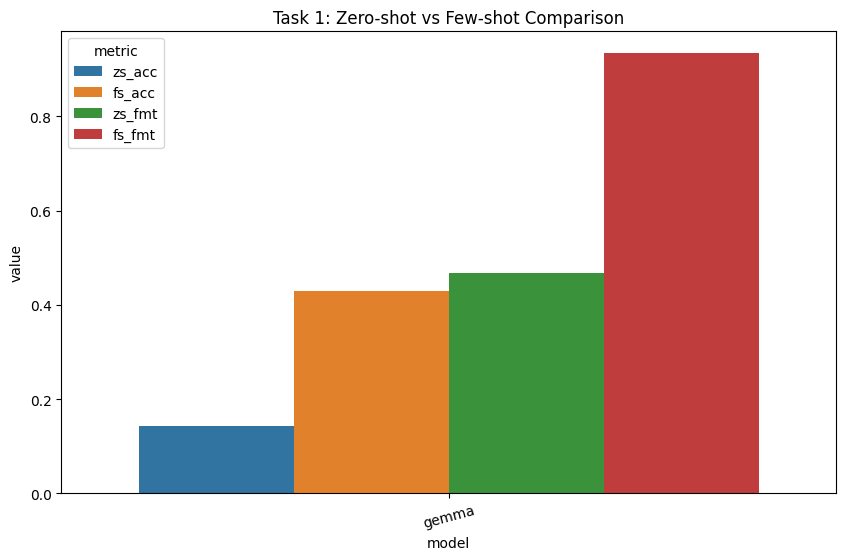

[{'model': 'gemma',
  'zs_acc': 0.14285714285714285,
  'zs_f1': 0.13333333333333333,
  'zs_fmt': 0.4666666666666667,
  'fs_acc': 0.42857142857142855,
  'fs_f1': 0.24848484848484848,
  'fs_fmt': 0.9333333333333333}]

In [99]:
models_dict = {
    "gemma": {
        "zs": zero_shot_classify,
        "fs": few_shot_classify
    }
}

RESULTS_DIR = os.path.expanduser("~/results")
os.makedirs(RESULTS_DIR, exist_ok=True)
results_path = os.path.join(RESULTS_DIR, "task1_results.json")

run_task1_comparison(
    dataset=dataset,
    models_dict=models_dict,
    results_path=results_path,
    sample_size=15
)

---

## Results Summary

Three metrics matter here: **Accuracy** measures exact star match, **Macro F1** checks whether performance is balanced across classes, and **JSON Compliance** measures whether the output can be parsed at all. This distinction is important because format failures should not be hidden inside accuracy alone.


In [100]:
def show_results_table(results):
    if 'results' not in globals():
        print("Run the classification loop first.")
        return pd.DataFrame()

    rows = []
    for key, ok_key, label in [
        ("zs_stars", "zs_format_ok", "Zero-shot"),
        ("fs_stars", "fs_format_ok", "Few-shot"),
    ]:
        valid = [(r["true_stars"], r[key]) for r in results if r.get(key) is not None]
        acc = accuracy_score([x[0] for x in valid], [x[1] for x in valid]) if valid else 0
        f1 = f1_score([x[0] for x in valid], [x[1] for x in valid], average="macro") if valid else 0
        fmt = sum(r[ok_key] for r in results) / len(results)
        rows.append({
            "Method": label,
            "Accuracy": f"{acc:.1%}",
            "Macro F1": f"{f1:.3f}",
            "JSON Compliance": f"{fmt:.1%}",
            "Valid Predictions": f"{len(valid)}/{len(results)}",
        })

    return pd.DataFrame(rows).set_index("Method")


show_results_table(results)

,Accuracy,Macro F1,JSON Compliance,Valid Predictions
Method,,,,
Zero-shot,14.3%,0.133,46.7%,7/15
Few-shot,42.9%,0.248,93.3%,14/15


## Per-Star Breakdown

Overall accuracy can hide rating collapse. This table shows whether the model is learning the full 1-5 scale or mostly predicting a narrow band of ratings. That matters because middle-star reviews are often the most ambiguous.


In [101]:
def per_star_breakdown(results):
    if 'results' not in globals():
        print("Run the classification loop first.")
        return pd.DataFrame()

    methods = [("zs_stars", "Zero-shot"), ("fs_stars", "Few-shot")]
    rows = []
    for star in range(1, 6):
        row = {"True ★": star}
        subset = [r for r in results if r["true_stars"] == star]
        total = len(subset)
        for key, label in methods:
            correct = sum(1 for r in subset if r.get(key) == star)
            row[label] = f"{correct}/{total} ({correct/total:.0%})" if total > 0 else "—"
        rows.append(row)

    return pd.DataFrame(rows).set_index("True ★")


per_star_breakdown(results)

,Zero-shot,Few-shot
True ★,,
1,0/6 (0%),5/6 (83%)
2,0/3 (0%),0/3 (0%)
3,0/2 (0%),1/2 (50%)
4,1/4 (25%),0/4 (0%)
5,—,—


## Confusion Matrices

The confusion matrices show how severe the mistakes are. Predicting 2-star for a 1-star review is different from predicting 5-star for a 1-star review, even though both are counted as wrong by accuracy.


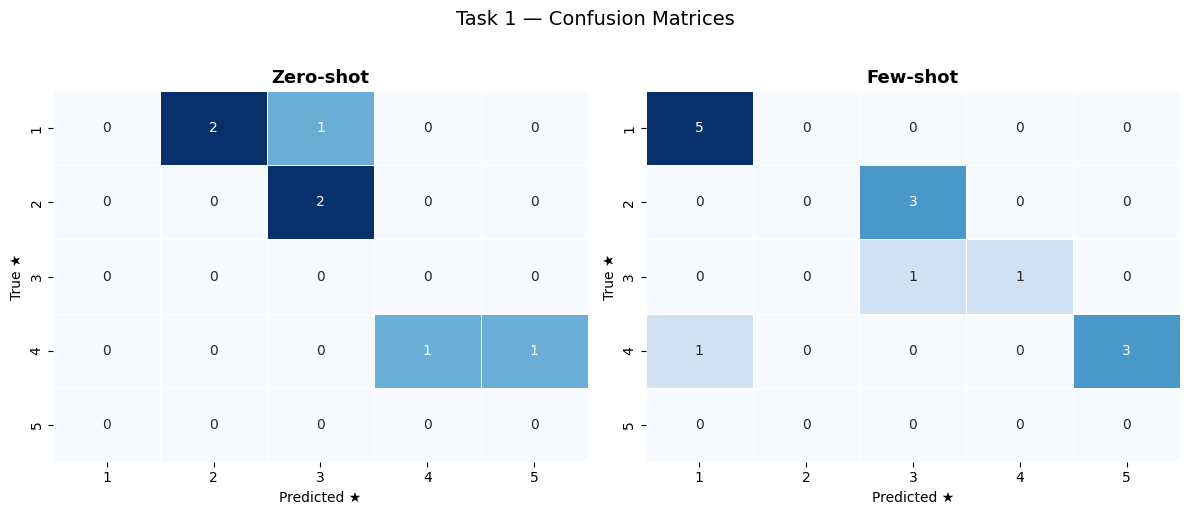

In [102]:
from sklearn.metrics import confusion_matrix


def plot_confusion_matrices(results):
    if 'results' not in globals():
        print("Run the classification loop first.")
        return

    methods = [("zs_stars", "Zero-shot"), ("fs_stars", "Few-shot")]
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    for ax, (key, name) in zip(axes, methods):
        valid = [(r["true_stars"], r[key]) for r in results if r.get(key) is not None]
        if not valid:
            ax.set_title(f"{name} — no valid predictions")
            ax.axis("off")
            continue
        y_true, y_pred = zip(*valid)
        cm = confusion_matrix(list(y_true), list(y_pred), labels=[1, 2, 3, 4, 5])
        sns.heatmap(
            cm, annot=True, fmt="d", ax=ax,
            xticklabels=[1, 2, 3, 4, 5], yticklabels=[1, 2, 3, 4, 5],
            cmap="Blues", cbar=False, linewidths=0.4,
        )
        ax.set_title(name, fontsize=13, fontweight="bold")
        ax.set_xlabel("Predicted ★")
        ax.set_ylabel("True ★")

    plt.suptitle("Task 1 — Confusion Matrices", fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()


plot_confusion_matrices(results)

## Error Analysis

The error table helps identify which reviews drove the largest misses. This supports prompt iteration because the worst cases often reveal whether the problem is sarcasm, mixed sentiment, formatting, or rating-scale calibration.


In [103]:
def show_error_analysis(results, dataset):
    if 'results' not in globals():
        print("Run the classification loop first.")
        return pd.DataFrame()

    rows = []
    for i, (row, sample) in enumerate(zip(results, dataset)):
        for key, label in [("zs_stars", "Zero-shot"), ("fs_stars", "Few-shot")]:
            pred = row.get(key)
            true = row["true_stars"]
            if pred is not None and pred != true:
                rows.append({
                    "Sample": i + 1,
                    "Method": label,
                    "True ★": true,
                    "Predicted ★": pred,
                    "Off By": abs(pred - true),
                    "Snippet": sample["text"][:90].replace("\n", " ") + "…",
                })

    if not rows:
        print("No errors — perfect run!")
        return pd.DataFrame()

    df = pd.DataFrame(rows).sort_values(["Off By", "Sample"], ascending=[False, True]).reset_index(drop=True)
    print(f"Total misclassifications across both methods: {len(df)}")
    return df


error_df = show_error_analysis(results, dataset)
error_df.head(20)

Total misclassifications across both methods: 14


,Sample,Method,True ★,Predicted ★,Off By,Snippet
0,9,Few-shot,4,1,3,"My friend is a piano teacher, so I took it as ..."
1,1,Zero-shot,1,3,2,I got 'new' tires from them and within two wee...
2,3,Zero-shot,1,2,1,All I can say is the worst! We were the only 2...
3,4,Zero-shot,1,2,1,I have been to this restaurant twice and was d...
4,7,Zero-shot,2,3,1,Typical Starbucks coffee chain. 2 things I don...
5,7,Few-shot,2,3,1,Typical Starbucks coffee chain. 2 things I don...
6,8,Few-shot,4,5,1,So.Much.Fun! \n\nI WISH I could play a song at...
7,10,Few-shot,3,4,1,Stopped by on a Mon evening after trying to di...
8,11,Zero-shot,2,3,1,"Think Chuck E. Cheese for adults. Skee Ball, ..."
9,11,Few-shot,2,3,1,"Think Chuck E. Cheese for adults. Skee Ball, ..."


---

## Key Takeaways

- **Few-shot improves JSON compliance and accuracy.** This suggests that examples help Gemma 2B learn the output protocol as much as the sentiment task.
- **Zero-shot failures are largely formatting failures.** The model often moves toward explanation instead of returning parseable JSON, which makes stricter output constraints a useful next step.
- **The API pivot is part of the result.** Gemini rate limits and Claude credit exhaustion made local inference necessary. This indicates that practical LLM systems need fallback paths, not just a preferred model.
- **The missing chat template limits Task 1.** Later tasks use `apply_chat_template`, so Task 1 should be read as both a prompting experiment and a reminder that inference formatting affects model behaviour.


---

## Prompt Iteration Framework

The following cells make it possible to test prompt variants without rerunning the entire notebook. This supports a controlled workflow: change one prompt decision, run the same evaluation, and compare how accuracy and JSON compliance move.

**Workflow:**
1. Define a new prompt string, such as `ZERO_SHOT_V2`.
2. Call `run_task1_eval(zero_shot_system=ZERO_SHOT_V2, label="v2 - describe the change")`.
3. Repeat for additional variants.
4. Call `compare_task1_iterations()` to compare the metrics.


In [104]:
iteration_log_t1 = []


def run_task1_eval(zero_shot_system=None, few_shot_examples=None, n=15, label="unnamed"):
    """Evaluate ZS and FS with the given prompts on n samples.

    Any argument left as None falls back to the current notebook-level variable.
    Results are appended to iteration_log_t1.

    Example — try removing the explanation field:
        run_task1_eval(zero_shot_system=ZERO_SHOT_SYSTEM_V2, label="v2 — no explanation")
    """
    _zs = zero_shot_system or ZERO_SHOT_SYSTEM
    _fs = few_shot_examples or FEW_SHOT_EXAMPLES

    sample   = dataset.select(range(min(n, len(dataset))))
    _results = []

    for row in sample:
        zs_raw = llm_call(f"Review: {row['text'][:250]}", _zs)
        fs_raw = llm_call(_fs + f"\n\nReview: {row['text'][:250]}", _zs)

        zs_cleaned = clean_json(zs_raw)
        fs_cleaned = clean_json(fs_raw)

        zs_parsed, zs_ok = safe_parse(zs_cleaned)
        fs_parsed, fs_ok = safe_parse(fs_cleaned)

        def _get_stars(parsed, ok):
            if ok and isinstance(parsed, dict):
                s = parsed.get("stars")
                if isinstance(s, int) and 1 <= s <= 5:
                    return s
            return None

        _results.append({
            "true_stars":   row["stars"],
            "zs_stars":     _get_stars(zs_parsed, zs_ok),
            "fs_stars":     _get_stars(fs_parsed, fs_ok),
            "zs_format_ok": zs_ok,
            "fs_format_ok": fs_ok,
        })

    def _m(key, ok_key):
        valid = [(r["true_stars"], r[key]) for r in _results if r.get(key) is not None]
        if not valid:
            return 0.0, 0.0, 0.0
        acc = accuracy_score([x[0] for x in valid], [x[1] for x in valid])
        f1  = f1_score([x[0] for x in valid], [x[1] for x in valid],
                       average="macro", zero_division=0)
        fmt = sum(r[ok_key] for r in _results) / len(_results)
        return round(acc, 3), round(f1, 3), round(fmt, 3)

    entry = {
        "label":     label,
        "Zero-shot": _m("zs_stars", "zs_format_ok"),
        "Few-shot":  _m("fs_stars", "fs_format_ok"),
    }
    iteration_log_t1.append(entry)

    print(f"\n[{label}]")
    for method, vals in entry.items():
        if method == "label":
            continue
        acc, f1, fmt = vals
        print(f"  {method:<12}  acc={acc:.3f}  f1={f1:.3f}  json={fmt:.2f}")

    return entry

In [105]:
run_task1_eval(label="v1 — baseline")


[v1 — baseline]
  Zero-shot     acc=0.143  f1=0.133  json=0.47
  Few-shot      acc=0.500  f1=0.342  json=0.93


{'label': 'v1 — baseline',
 'Zero-shot': (0.143, 0.133, 0.467),
 'Few-shot': (0.5, 0.342, 0.933)}

## Comparing Prompt Iterations

The chart shows whether each prompt change improved accuracy, compliance, or both. This matters because a prompt that improves sentiment reasoning but breaks JSON is not useful for an automated classifier.


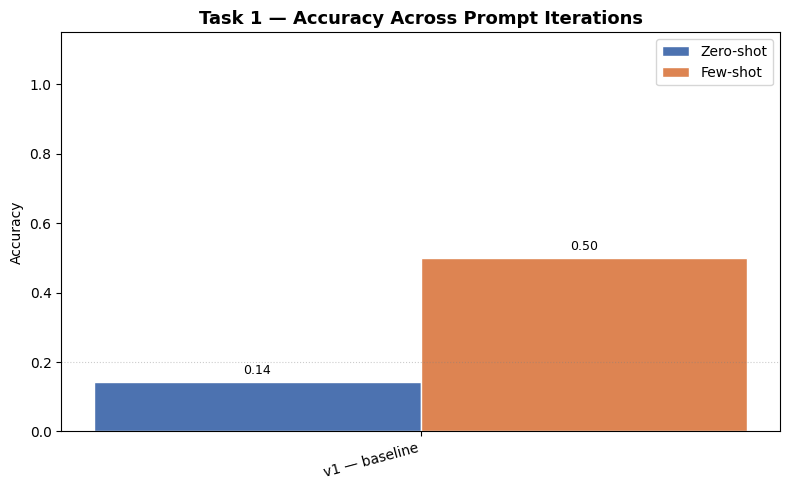

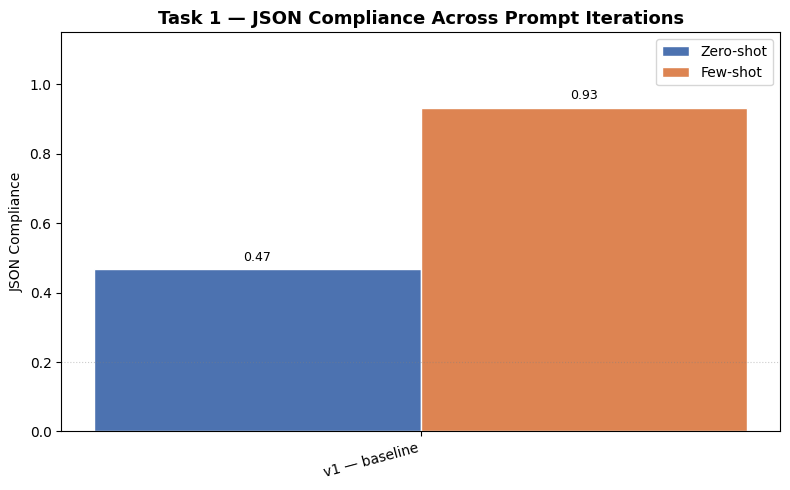

In [106]:
def compare_task1_iterations(metric="acc"):
    """Plot how ZS and FS metrics changed across all logged iterations.

    metric: 'acc' (accuracy), 'f1' (macro F1), or 'json' (JSON compliance)
    """
    if not iteration_log_t1:
        print("No iterations yet — call run_task1_eval() first.")
        return

    idx     = {"acc": 0, "f1": 1, "json": 2}[metric]
    labels  = [e["label"] for e in iteration_log_t1]
    methods = ["Zero-shot", "Few-shot"]
    colors  = ["#4C72B0", "#DD8452"]

    x     = list(range(len(labels)))
    width = 0.30
    fig, ax = plt.subplots(figsize=(max(8, len(labels) * 2.5), 5))

    for i, (method, color) in enumerate(zip(methods, colors)):
        pos  = [j + (i - 0.5) * width for j in x]
        vals = [e[method][idx] for e in iteration_log_t1]
        bars = ax.bar(pos, vals, width, label=method, color=color, edgecolor="white")
        for bar, val in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.015,
                    f"{val:.2f}", ha="center", va="bottom", fontsize=9)

    metric_name = {"acc": "Accuracy", "f1": "Macro F1", "json": "JSON Compliance"}[metric]
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=15, ha="right", fontsize=10)
    ax.set_ylim(0, 1.15)
    ax.set_ylabel(metric_name)
    ax.set_title(f"Task 1 — {metric_name} Across Prompt Iterations",
                 fontsize=13, fontweight="bold")
    ax.legend(loc="upper right", fontsize=10)
    ax.axhline(0.2, color="gray", linestyle=":", linewidth=0.8, alpha=0.4)
    plt.tight_layout()
    plt.show()


compare_task1_iterations(metric="acc")
compare_task1_iterations(metric="json")

In [107]:
print("\n=== FINAL COMPARISON ===")

try:
    _zs = zs_acc
    _fs = fs_acc
except NameError:
    valid_zs = [(r["true_stars"], r["zs_stars"]) for r in results if r.get("zs_stars") is not None]
    valid_fs = [(r["true_stars"], r["fs_stars"]) for r in results if r.get("fs_stars") is not None]
    _zs = accuracy_score([x[0] for x in valid_zs], [x[1] for x in valid_zs]) if valid_zs else 0.0
    _fs = accuracy_score([x[0] for x in valid_fs], [x[1] for x in valid_fs]) if valid_fs else 0.0

if _fs > _zs:
    print("Few-shot performs better than Zero-shot")
else:
    print("Zero-shot performs better than Few-shot")

print(f"Accuracy Gain: {_fs - _zs:.3f}")


=== FINAL COMPARISON ===
Few-shot performs better than Zero-shot
Accuracy Gain: 0.286


## Observations

- Few-shot prompting improves accuracy compared with zero-shot.
- JSON compliance improves when the model sees structured examples.
- Zero-shot outputs are more inconsistent and more prone to formatting errors.


In [108]:
print("\n=== SAMPLE FAILURES ===")

count = 0

for r in results:
    if r.get("zs_stars") != r["true_stars"] or r.get("fs_stars") != r["true_stars"]:
        print("\nTrue:", r["true_stars"])
        print("Zero-shot:", r.get("zs_stars"))
        print("Few-shot:", r.get("fs_stars"))
        count += 1

    if count >= 5:
        break


=== SAMPLE FAILURES ===

True: 1
Zero-shot: 3
Few-shot: 1

True: 1
Zero-shot: None
Few-shot: 1

True: 1
Zero-shot: 2
Few-shot: 1

True: 1
Zero-shot: 2
Few-shot: 1

True: 1
Zero-shot: None
Few-shot: None


## Why Few-Shot Works

Few-shot prompting gives the model concrete examples of the mapping between review text and star ratings. This reduces ambiguity in both the task and the output format, which is especially important for a smaller local model.


---

## Analysis and Conclusion

Zero-shot scored 14.3% accuracy with 47% JSON compliance, leaving only 7 of 15 samples with valid predictions. Few-shot improved the main results loop to 42.9% accuracy, reached 93% JSON compliance, and produced 14 of 15 valid predictions. In the prompt-iteration run, few-shot reached 50% accuracy. This suggests the model had enough sentiment knowledge to improve once the output format was anchored.

The per-star breakdown gives the clearest explanation: zero-shot never correctly classified 1-star or 2-star reviews, while few-shot recovered 1-star reviews much more reliably. The practical constraint is also part of the result: Gemini hit rate limits, Claude ran out of free-tier credits, and local Gemma kept the experiment moving. The remaining ceiling likely reflects both model size and the raw-concatenation inference path used in this first task.

### What This Task Measures

Task 1 compares **zero-shot** prompting against **few-shot** prompting. The core question is whether examples improve only accuracy, or whether they also make the output format reliable enough for automated evaluation.

### Suggested Next Iterations

1. Add a stricter JSON-only ending to the zero-shot prompt.
2. Test a smaller output schema such as `{"stars": N}`.
3. Re-run Task 1 with `apply_chat_template` so the inference pipeline matches Tasks 2 and 3.
